In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime 
import statistics 


In [2]:
df = pd.read_csv('data/cleaned/online_retail_cleaned.csv')
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,MonthName,Day,Weekday,Hour,YearMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010,12,December,1,Wednesday,8,2010-12-01
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12-01
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010,12,December,1,Wednesday,8,2010-12-01
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12-01
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010,12,December,1,Wednesday,8,2010-12-01
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850,United Kingdom,15.30,2010,12,December,1,Wednesday,8,2010-12-01
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850,United Kingdom,25.50,2010,12,December,1,Wednesday,8,2010-12-01
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010,12,December,1,Wednesday,8,2010-12-01
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850,United Kingdom,11.10,2010,12,December,1,Wednesday,8,2010-12-01
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047,United Kingdom,54.08,2010,12,December,1,Wednesday,8,2010-12-01


In [3]:
df.shape

(392692, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  str    
 2   Description  392692 non-null  str    
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  str    
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  int64  
 7   Country      392692 non-null  str    
 8   Revenue      392692 non-null  float64
 9   Year         392692 non-null  int64  
 10  Month        392692 non-null  int64  
 11  MonthName    392692 non-null  str    
 12  Day          392692 non-null  int64  
 13  Weekday      392692 non-null  str    
 14  Hour         392692 non-null  int64  
 15  YearMonth    392692 non-null  str    
dtypes: float64(2), int64(7), str(7)
memory usage: 80.7 MB


In [5]:
#Check for Missing Values
print('\n Missing data : ')
print(df.isnull().sum())


 Missing data : 
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
Year           0
Month          0
MonthName      0
Day            0
Weekday        0
Hour           0
YearMonth      0
dtype: int64


In [6]:
print("Duplicated data: ", df.duplicated().sum())

Duplicated data:  0


In [7]:
print ("First business transaction date is {}".format(df.InvoiceDate.min()))
print ("Last business transaction  date is {}".format(df.InvoiceDate.max()))

First business transaction date is 2010-12-01 08:26:00
Last business transaction  date is 2011-12-09 12:50:00


In [8]:
for col in ['Quantity', 'UnitPrice', 'Revenue']:
    print(f"--- Thống kê biến: {col} ---")
    print((df[col] > 0).value_counts().rename({True: 'Khác 0 (>0)', False: 'Bằng hoặc nhỏ hơn 0 (<=0)'}))
    print("\n")

--- Thống kê biến: Quantity ---
Quantity
Khác 0 (>0)    392692
Name: count, dtype: int64


--- Thống kê biến: UnitPrice ---
UnitPrice
Khác 0 (>0)    392692
Name: count, dtype: int64


--- Thống kê biến: Revenue ---
Revenue
Khác 0 (>0)    392692
Name: count, dtype: int64




### **RFM Analysis**

In [9]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

#### ***Calculate Recency***

In [12]:
recency = (
    df.groupby('CustomerID')['InvoiceDate']
    .max()
    .reset_index()
)

recency.columns = ['CustomerID', 'LastPurchaseDate']

recency['Recency'] = (
    snapshot_date - recency['LastPurchaseDate']
).dt.days

#### ***Calculate Frequency***

In [13]:
frequency = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .reset_index()
)

frequency.columns = ['CustomerID', 'Frequency']

#### ***Calculate Monetary***

In [14]:
monetary = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .reset_index()
)

monetary.columns = ['CustomerID', 'Monetary']

In [15]:
rfm = recency.merge(frequency, on='CustomerID')
rfm = rfm.merge(monetary, on='CustomerID')

In [17]:
rfm.drop(columns='LastPurchaseDate', inplace=True)

In [18]:
# Create labels for the ranks (1 is worst, 4 is best)
r_labels = range(4, 0, -1) # Output: [4, 3, 2, 1] - Reversed for Recency
f_labels = range(1, 5)     # Output: [1, 2, 3, 4]
m_labels = range(1, 5)     # Output: [1, 2, 3, 4]

# Assign ranks
rfm['R_Rank'] = pd.qcut(rfm['Recency'], q=4, labels=r_labels)

# Note: We use .rank(method='first') for Frequency because many customers might 
# have the exact same frequency (e.g., 1 purchase), which can cause a pandas error.
rfm['F_Rank'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=f_labels)
rfm['M_Rank'] = pd.qcut(rfm['Monetary'], q=4, labels=m_labels)

In [19]:
# Convert ranks to strings and combine them
rfm['RFM_Score'] = rfm['R_Rank'].astype(str) + rfm['F_Rank'].astype(str) + rfm['M_Rank'].astype(str)

In [20]:
def segment_customer(df):
    score = df['RFM_Score']
    
    if score == '444':
        return 'VIP / Champions'
    elif score.startswith('4') or score.startswith('3'):
        # Recent shoppers with decent frequency/monetary
        return 'Loyal / Potential Loyalists'
    elif score.startswith('1') and df['F_Rank'] >= 3:
        # High frequency, but haven't purchased in a long time
        return 'At Risk / Needs Attention'
    elif score == '111':
        # Low recency, low frequency, low monetary
        return 'Lost Customers'
    else:
        return 'Regular / Average'

# Apply the function to create a new column
rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)


In [21]:
print(rfm.head())

   CustomerID  Recency  Frequency  Monetary R_Rank F_Rank M_Rank RFM_Score  \
0       12346      326          1  77183.60      1      1      4       114   
1       12347        2          7   4310.00      4      4      4       444   
2       12348       75          4   1797.24      2      3      4       234   
3       12349       19          1   1757.55      3      1      4       314   
4       12350      310          1    334.40      1      1      2       112   

              Customer_Segment  
0            Regular / Average  
1              VIP / Champions  
2            Regular / Average  
3  Loyal / Potential Loyalists  
4            Regular / Average  


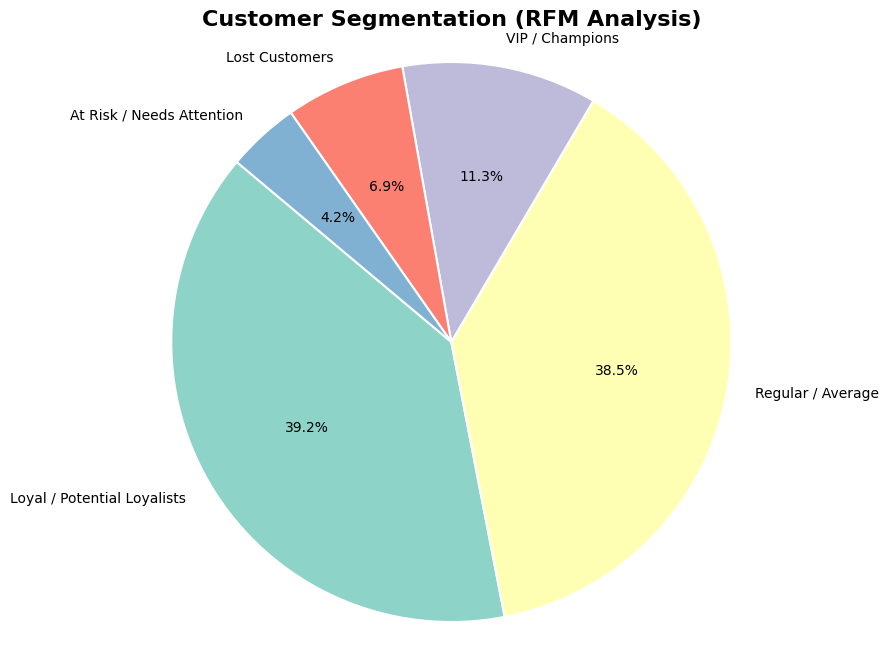

In [22]:
# 1. Count the number of customers in each segment
segment_counts = rfm['Customer_Segment'].value_counts()

# 2. Set up the figure size
plt.figure(figsize=(10, 8))

# 3. Create the pie chart
# autopct='%1.1f%%' adds the percentage labels to each slice
# startangle=140 rotates the start of the pie chart for better aesthetics
plt.pie(
    segment_counts.values, 
    labels=segment_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=plt.cm.Set3.colors, # Using a nice pastel color map
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5} # Adds clean white borders between slices
)

# 4. Add a title
plt.title('Customer Segmentation (RFM Analysis)', fontsize=16, fontweight='bold')

# 5. Ensure the pie chart is drawn as a perfect circle
plt.axis('equal') 

# 6. Display the plot
plt.show()

In [23]:
print(rfm.describe())

         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2048.688081
std     1721.808492   100.014169     7.697998    8985.230220
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     306.482500
50%    15299.500000    51.000000     2.000000     668.570000
75%    16778.750000   142.000000     5.000000    1660.597500
max    18287.000000   374.000000   209.000000  280206.020000


In [24]:
ranking_columns = ['R_Rank', 'F_Rank', 'M_Rank']
for col in ranking_columns:
    print(f"--- Thống kê biến: {col} ---")
    print(rfm[col].value_counts().sort_index())
    print("\n")

--- Thống kê biến: R_Rank ---
R_Rank
4    1125
3    1063
2    1066
1    1084
Name: count, dtype: int64


--- Thống kê biến: F_Rank ---
F_Rank
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64


--- Thống kê biến: M_Rank ---
M_Rank
1    1085
2    1084
3    1084
4    1085
Name: count, dtype: int64




In [26]:
# Calculate the average Recency, Frequency, and Monetary value for each segment
segment_means = rfm.groupby('Customer_Segment')[['Recency', 'Frequency', 'Monetary']].mean().reset_index()

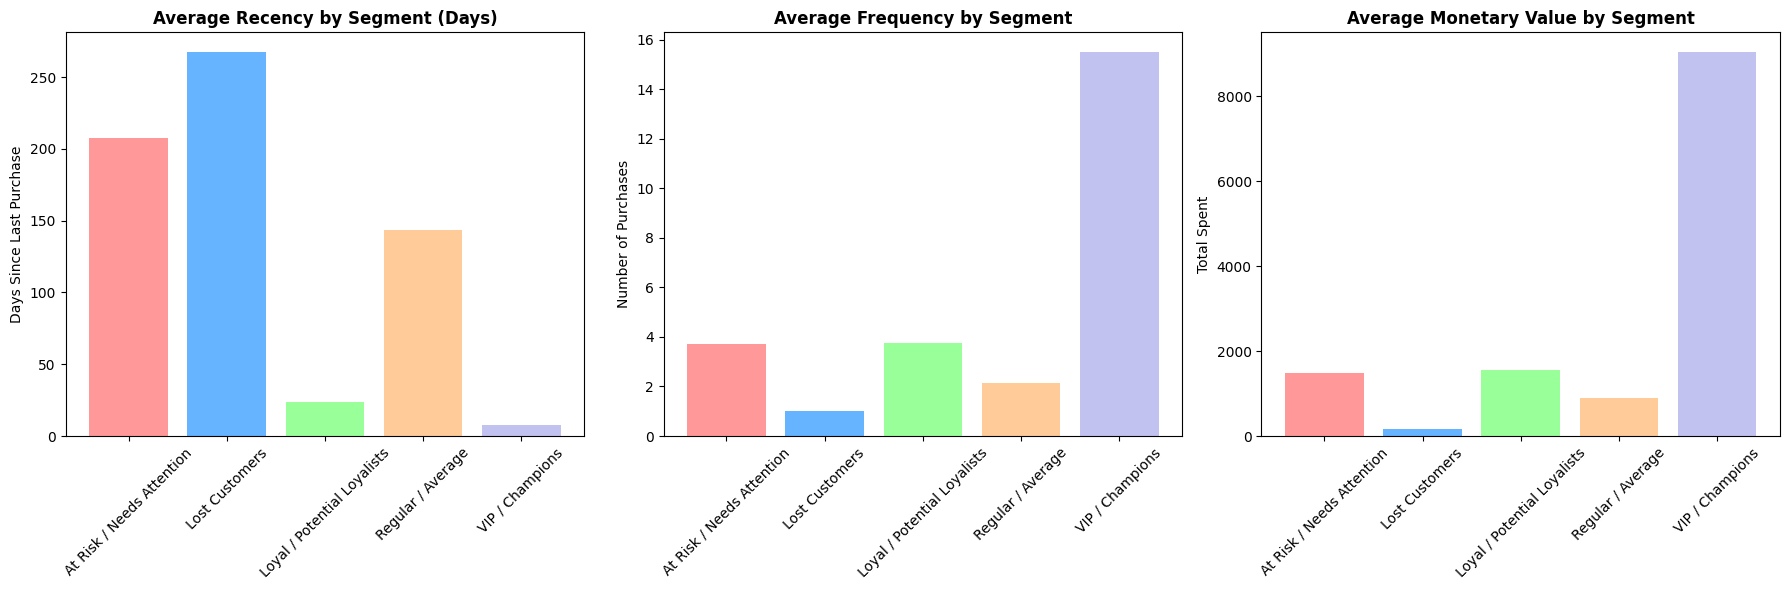

In [27]:
# Set up a figure with 3 subplots side-by-side (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Define a color palette for the segments
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#c2c2f0']

# --- Chart 1: Recency ---
# Note: For Recency, a lower bar is actually better!
axes[0].bar(segment_means['Customer_Segment'], segment_means['Recency'], color=colors)
axes[0].set_title('Average Recency by Segment (Days)', fontweight='bold')
axes[0].set_ylabel('Days Since Last Purchase')
axes[0].tick_params(axis='x', rotation=45) # Rotate labels so they don't overlap

# --- Chart 2: Frequency ---
axes[1].bar(segment_means['Customer_Segment'], segment_means['Frequency'], color=colors)
axes[1].set_title('Average Frequency by Segment', fontweight='bold')
axes[1].set_ylabel('Number of Purchases')
axes[1].tick_params(axis='x', rotation=45)

# --- Chart 3: Monetary ---
axes[2].bar(segment_means['Customer_Segment'], segment_means['Monetary'], color=colors)
axes[2].set_title('Average Monetary Value by Segment', fontweight='bold')
axes[2].set_ylabel('Total Spent')
axes[2].tick_params(axis='x', rotation=45)

# Adjust the layout so everything fits perfectly
plt.tight_layout()

# Display the charts
plt.show()

Training model 

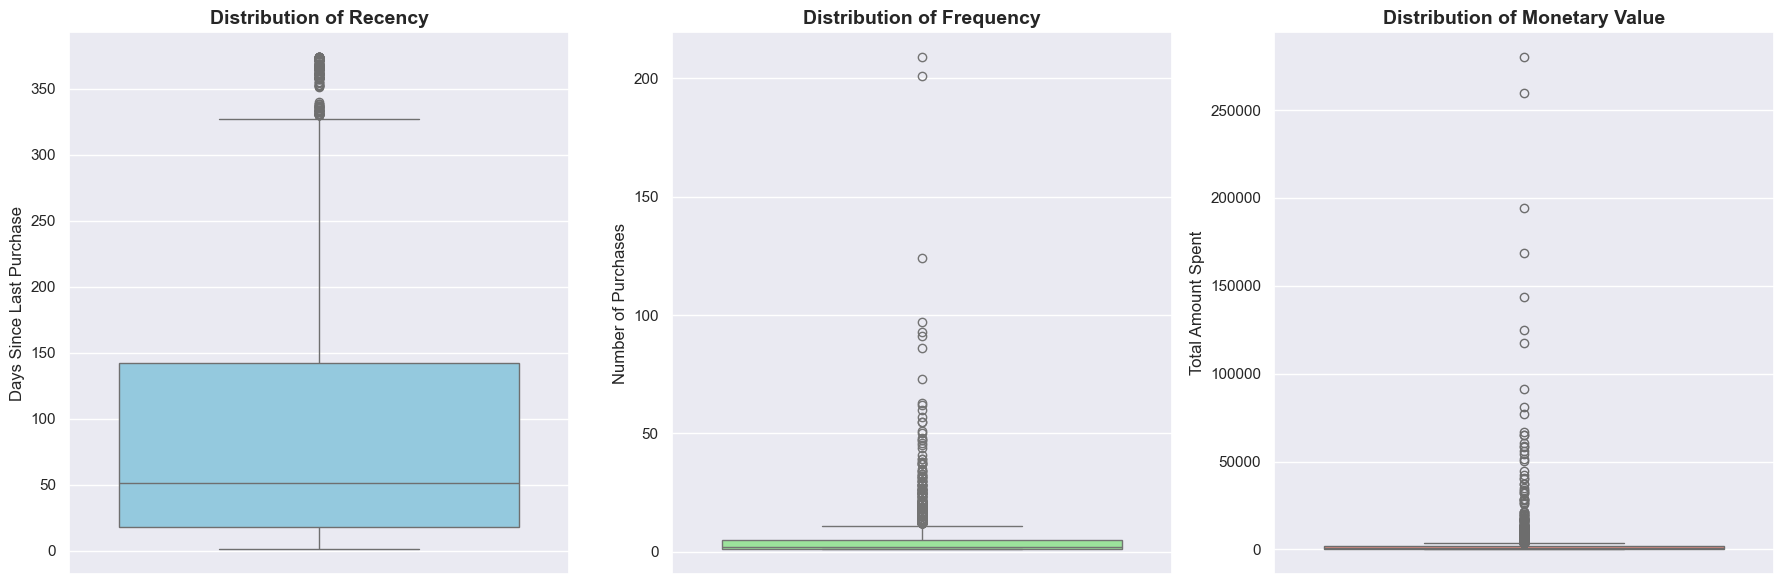

In [28]:
# Set a clean visual style
sns.set_theme(style="darkgrid")

# Create a figure with 3 subplots side-by-side (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Box Plot 1: Recency ---
sns.boxplot(y=rfm['Recency'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Recency', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Days Since Last Purchase')

# --- Box Plot 2: Frequency ---
sns.boxplot(y=rfm['Frequency'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribution of Frequency', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Purchases')

# --- Box Plot 3: Monetary ---
sns.boxplot(y=rfm['Monetary'], ax=axes[2], color='salmon')
axes[2].set_title('Distribution of Monetary Value', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Total Amount Spent')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

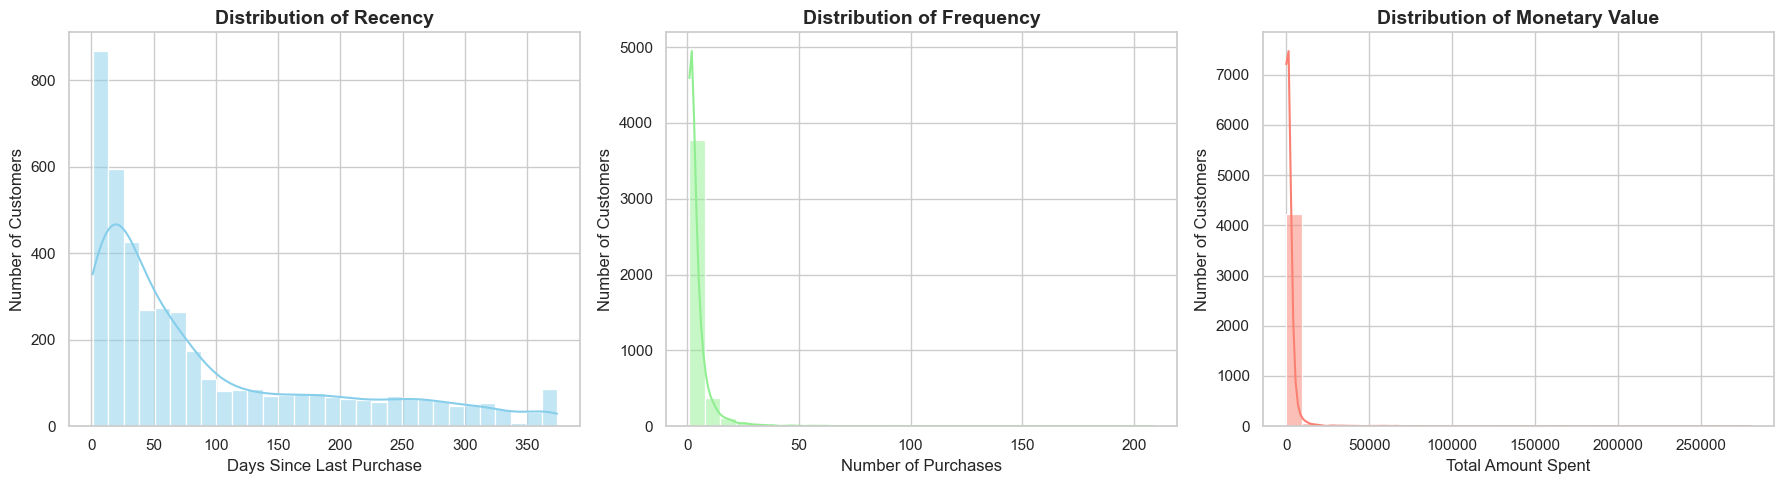

In [29]:

# Set a clean visual style
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots side-by-side (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Histogram 1: Recency ---
# bins=30 divides the data into 30 bars. kde=True adds the smooth trend line.
sns.histplot(rfm['Recency'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Distribution of Recency', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].set_ylabel('Number of Customers')

# --- Histogram 2: Frequency ---
sns.histplot(rfm['Frequency'], bins=30, kde=True, color='lightgreen', ax=axes[1])
axes[1].set_title('Distribution of Frequency', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Purchases')
axes[1].set_ylabel('Number of Customers')

# --- Histogram 3: Monetary ---
sns.histplot(rfm['Monetary'], bins=30, kde=True, color='salmon', ax=axes[2])
axes[2].set_title('Distribution of Monetary Value', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Total Amount Spent')
axes[2].set_ylabel('Number of Customers')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

In [30]:
from sklearn.preprocessing import StandardScaler

In [31]:
# --- 1. Log Transformation ---
# We use np.log1p(x) which calculates log(x + 1) safely to avoid errors if any value is 0
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(np.log1p, axis=1)

In [32]:
# --- 2. Handling Outliers (Capping / Winsorization) ---
def cap_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # np.clip replaces values outside the bounds with the bound values themselves
    return np.clip(series, lower_bound, upper_bound)

In [33]:
# Apply the capping function to our log-transformed data
rfm_capped = rfm_log.apply(cap_outliers_iqr, axis=0)

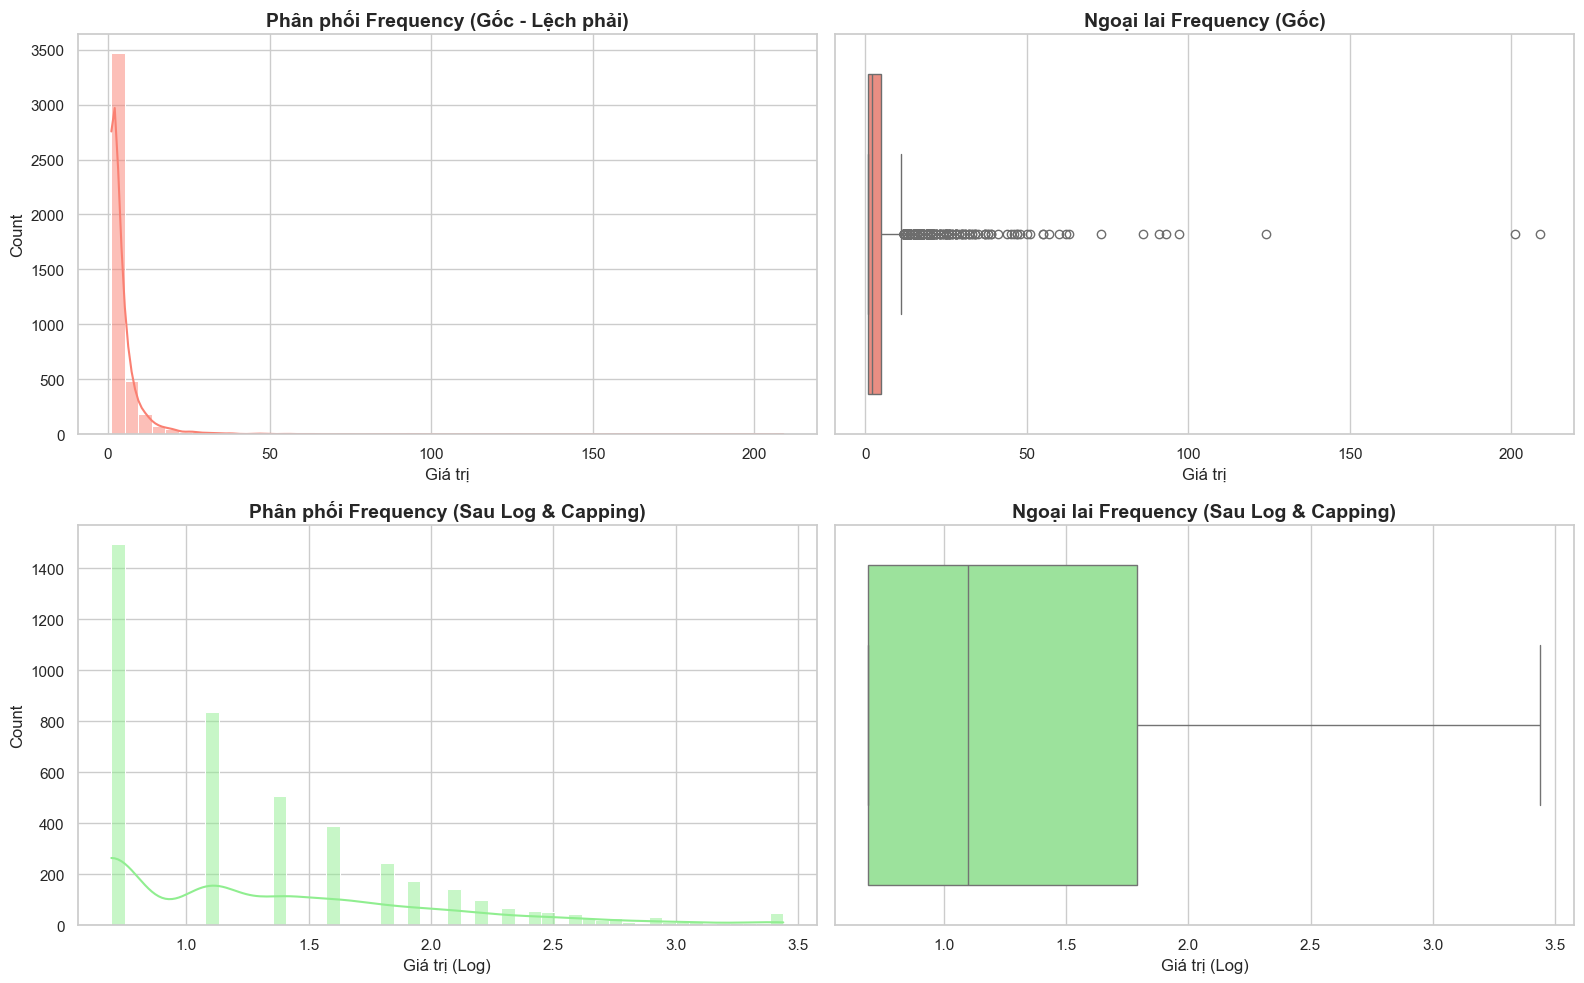

In [36]:
# Chọn biến để trực quan hóa ( thay bằng 'Recency' hoặc 'Frequency')
feature = 'Frequency'

# Thiết lập bố cục: 2 hàng (Trên: Gốc, Dưới: Đã xử lý), 2 cột (Trái: Phân phối, Phải: Ngoại lai)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.set_theme(style="whitegrid")

# ==========================================
# HÀNG 1: DỮ LIỆU GỐC (TRƯỚC KHI XỬ LÝ)
# ==========================================

# 1. Histogram (Biểu đồ phân phối) - Sẽ thấy lệch phải nặng
sns.histplot(rfm[feature], bins=50, kde=True, color='salmon', ax=axes[0, 0])
axes[0, 0].set_title(f'Phân phối {feature} (Gốc - Lệch phải)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Giá trị')

# 2. Boxplot (Biểu đồ hộp) - Sẽ thấy rất nhiều chấm đen (ngoại lai)
sns.boxplot(x=rfm[feature], color='salmon', ax=axes[0, 1])
axes[0, 1].set_title(f'Ngoại lai {feature} (Gốc)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Giá trị')

# ==========================================
# HÀNG 2: DỮ LIỆU ĐÃ XỬ LÝ (LOG + CAPPING)
# ==========================================
# Lưu ý: Sử dụng rfm_capped từ Giai đoạn 3

# 3. Histogram - Sẽ thấy phân phối giống hình quả chuông (Normal Distribution) hơn
sns.histplot(rfm_capped[feature], bins=50, kde=True, color='lightgreen', ax=axes[1, 0])
axes[1, 0].set_title(f'Phân phối {feature} (Sau Log & Capping)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Giá trị (Log)')

# 4. Boxplot - Sẽ thấy các chấm đen biến mất hoặc giảm hẳn do đã bị "chặn" (Capping)
sns.boxplot(x=rfm_capped[feature], color='lightgreen', ax=axes[1, 1])
axes[1, 1].set_title(f'Ngoại lai {feature} (Sau Log & Capping)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Giá trị (Log)')

# Căn chỉnh và hiển thị
plt.tight_layout()
plt.show()

In [37]:
# --- 3. Feature Scaling (StandardScaler) ---
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_capped)

In [38]:
# Convert the scaled array back into a Pandas DataFrame for easier usage in Phase 4
rfm_scaled_df = pd.DataFrame(
    rfm_scaled, 
    index=rfm.index, 
    columns=['Recency', 'Frequency', 'Monetary']
)

In [39]:
print("Pre-processing complete. Here is the scaled data:")
print(rfm_scaled_df.head())

Pre-processing complete. Here is the scaled data:
    Recency  Frequency  Monetary
0  1.461993  -0.973928  2.746797
1 -2.038734   1.110579  1.459173
2  0.373104   0.403856  0.745384
3 -0.623086  -0.973928  0.727164
4  1.424558  -0.973928 -0.625472


### **Clustering**

In [40]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [41]:
sse = {}
silhouette_scores = []
k_range = range(2, 11) # Testing K from 2 to 10

In [42]:
# Run K-Means for each K and calculate metrics
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    
    # Sum of Squared Errors (for the Elbow Method)
    sse[k] = kmeans.inertia_
    
    # Silhouette Score
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(rfm_scaled_df, labels))

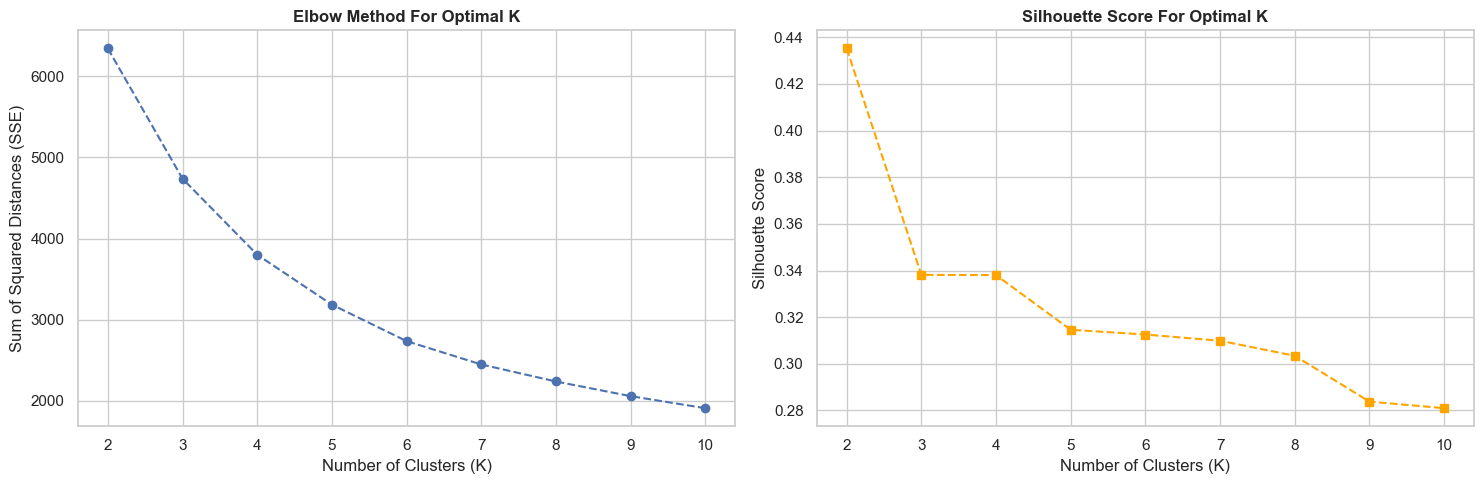

In [43]:
# --- Plotting the Results ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Elbow Curve
axes[0].plot(list(sse.keys()), list(sse.values()), marker='o', linestyle='--', color='b')
axes[0].set_title('Elbow Method For Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Sum of Squared Distances (SSE)')

# Silhouette Score Curve
axes[1].plot(k_range, silhouette_scores, marker='s', linestyle='--', color='orange')
axes[1].set_title('Silhouette Score For Optimal K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

Executing the Final K-Means Model

In [44]:
# Choose the best K based on your visual analysis of the charts above
optimal_k = 4 

# Initialize and fit the final model
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['ML_Cluster'] = final_kmeans.fit_predict(rfm_scaled_df)

# Check the final output
print("Clustering complete! Here is your final dataset with Machine Learning segments:")
print(rfm[['Recency', 'Frequency', 'Monetary', 'RFM_Score', 'ML_Cluster']].head())

Clustering complete! Here is your final dataset with Machine Learning segments:
   Recency  Frequency  Monetary RFM_Score  ML_Cluster
0      326          1  77183.60       114           3
1        2          7   4310.00       444           1
2       75          4   1797.24       234           3
3       19          1   1757.55       314           2
4      310          1    334.40       112           0


EVALUATION & INSIGHTS

In [45]:
# 1. Cluster Profiling
cluster_analysis = rfm.groupby('ML_Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Customer_Count'}).reset_index()

In [46]:
# 2. Name Clusters dynamically (Example logic based on average means)
# Note: You should adjust this logic based on your actual data output
def name_ml_clusters(row):
    if row['ML_Cluster'] == 0: return 'Potential Customers'
    if row['ML_Cluster'] == 1: return 'VIP Customers'
    if row['ML_Cluster'] == 2: return 'Hibernating Customers'
    return 'Needs Attention'

In [47]:
cluster_analysis['ML_Segment_Name'] = cluster_analysis.apply(name_ml_clusters, axis=1)
rfm['ML_Segment_Name'] = rfm['ML_Cluster'].map(cluster_analysis.set_index('ML_Cluster')['ML_Segment_Name'])

print("--- Cluster Profile Summary ---")
print(cluster_analysis)

--- Cluster Profile Summary ---
   ML_Cluster     Recency  Frequency     Monetary  Customer_Count  \
0           0  186.609425   1.306004   332.426747            1549   
1           1   12.365079  13.302910  7737.614947             756   
2           2   19.367299   2.043839   522.240344             844   
3           3   72.894029   3.975610  1750.943745            1189   

         ML_Segment_Name  
0    Potential Customers  
1          VIP Customers  
2  Hibernating Customers  
3        Needs Attention  


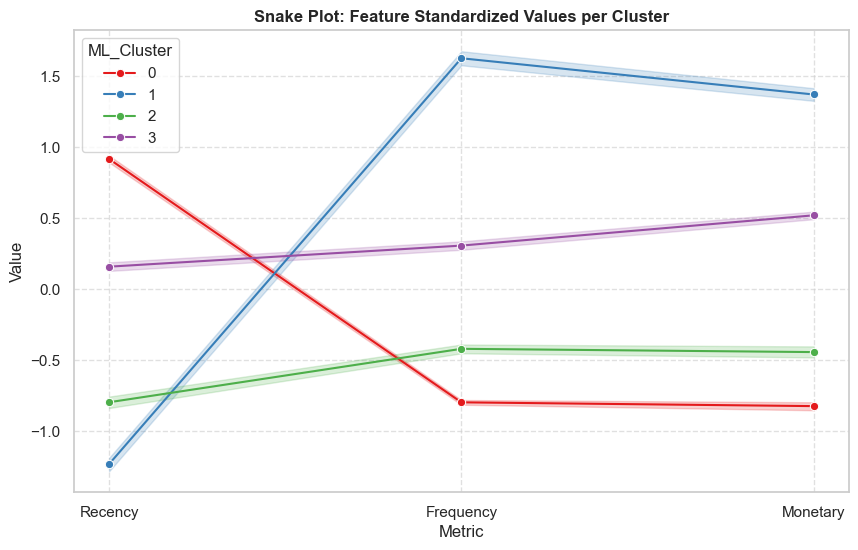

In [50]:
# 3. Snake Plot Visualization
rfm_scaled_df['CustomerID'] = rfm['CustomerID']
rfm_scaled_df['ML_Cluster'] = rfm['ML_Cluster']

# Now melt the dataframe (we don't even need reset_index() anymore)
rfm_melted = pd.melt(
    rfm_scaled_df, 
    id_vars=['CustomerID', 'ML_Cluster'],
    value_vars=['Recency', 'Frequency', 'Monetary'],
    var_name='Metric', 
    value_name='Value'
)

# Draw the plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=rfm_melted, x='Metric', y='Value', hue='ML_Cluster', palette='Set1', marker='o')
plt.title('Snake Plot: Feature Standardized Values per Cluster', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [51]:
# 4. Pareto Analysis (80/20 Rule)
total_revenue = rfm['Monetary'].sum()
pareto_df = rfm.groupby('ML_Segment_Name')['Monetary'].agg(['sum', 'count']).rename(columns={'sum': 'Total_Revenue', 'count': 'Customer_Count'})

pareto_df['Revenue_Share (%)'] = (pareto_df['Total_Revenue'] / total_revenue) * 100
pareto_df['Customer_Share (%)'] = (pareto_df['Customer_Count'] / len(rfm)) * 100

print("\n--- Pareto Analysis ---")
print(pareto_df[['Customer_Share (%)', 'Revenue_Share (%)']].round(2))


--- Pareto Analysis ---
                       Customer_Share (%)  Revenue_Share (%)
ML_Segment_Name                                             
Hibernating Customers               19.46               4.96
Needs Attention                     27.41              23.43
Potential Customers                 35.71               5.79
VIP Customers                       17.43              65.82


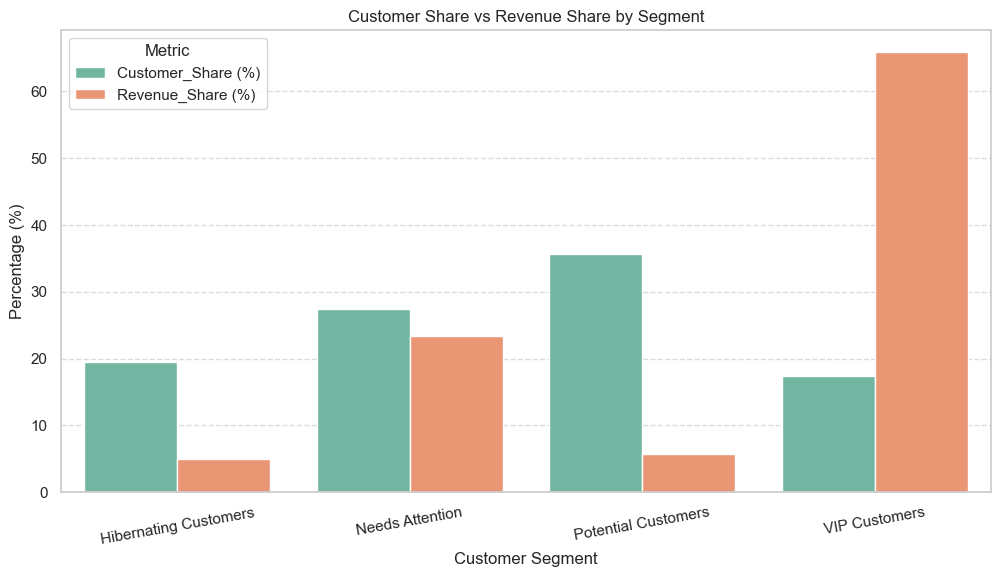

In [52]:
# Reset index for plotting
pareto_plot = pareto_df.reset_index()

plt.figure(figsize=(12,6))

# Convert to long format
pareto_melted = pareto_plot.melt(
    id_vars='ML_Segment_Name',
    value_vars=['Customer_Share (%)', 'Revenue_Share (%)'],
    var_name='Metric',
    value_name='Percentage'
)

sns.barplot(
    data=pareto_melted,
    x='ML_Segment_Name',
    y='Percentage',
    hue='Metric',
    palette='Set2'
)

plt.title('Customer Share vs Revenue Share by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

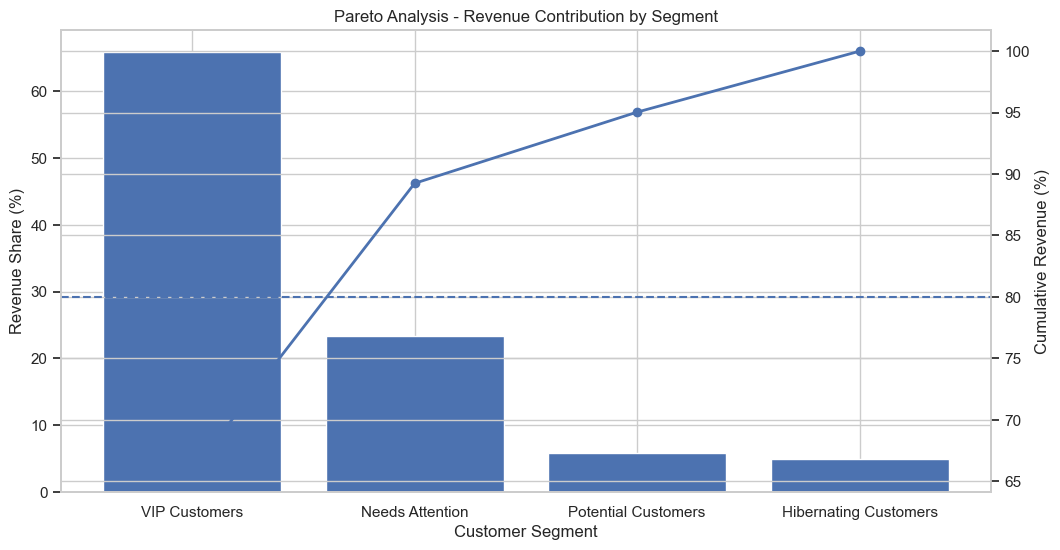

In [53]:
pareto_sorted = pareto_df.sort_values(
    by='Revenue_Share (%)',
    ascending=False
).reset_index()

pareto_sorted['Cumulative_Revenue (%)'] = pareto_sorted['Revenue_Share (%)'].cumsum()

fig, ax1 = plt.subplots(figsize=(12,6))

# Barplot
ax1.bar(
    pareto_sorted['ML_Segment_Name'],
    pareto_sorted['Revenue_Share (%)']
)

ax1.set_ylabel('Revenue Share (%)')
ax1.set_xlabel('Customer Segment')
ax1.set_title('Pareto Analysis - Revenue Contribution by Segment')

# Cumulative line
ax2 = ax1.twinx()

ax2.plot(
    pareto_sorted['ML_Segment_Name'],
    pareto_sorted['Cumulative_Revenue (%)'],
    marker='o',
    linewidth=2
)

ax2.set_ylabel('Cumulative Revenue (%)')
ax2.axhline(80, linestyle='--')

plt.show()

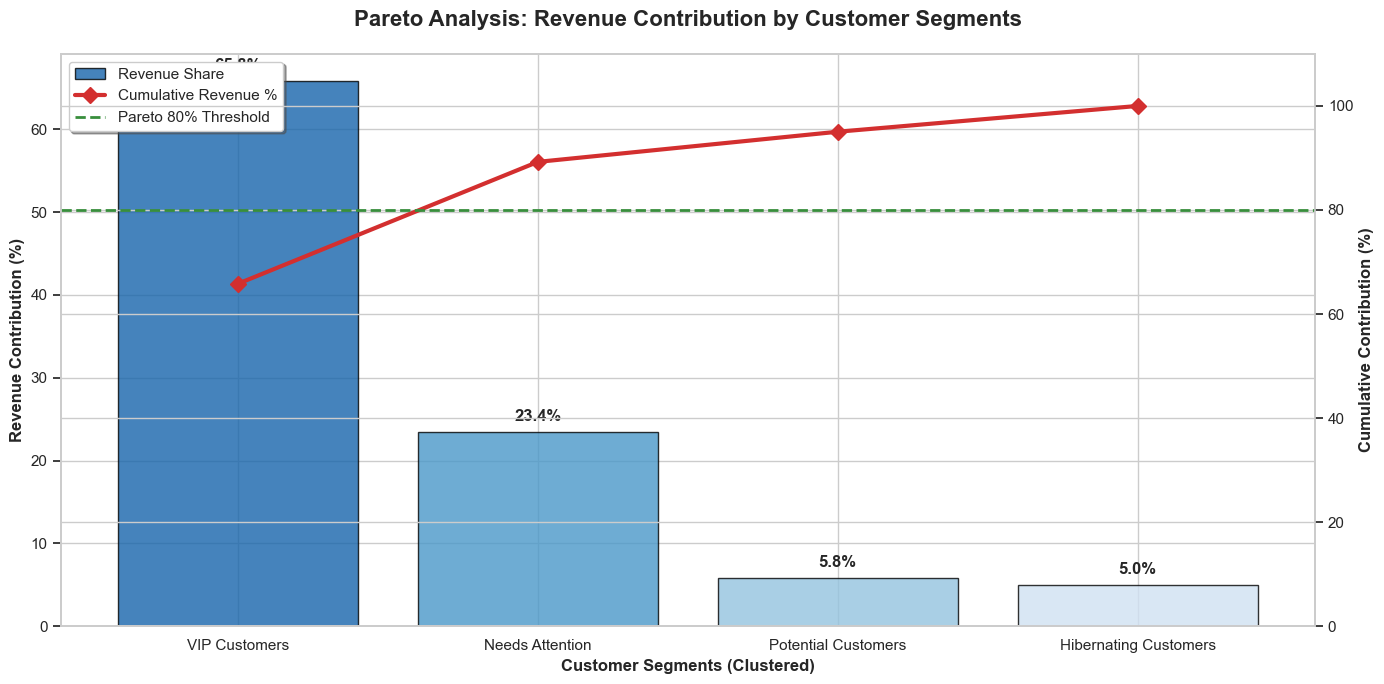

In [56]:

sns.set_style("whitegrid")
fig, ax1 = plt.subplots(figsize=(14, 7))

# 1. Vẽ Barplot (Doanh thu của từng phân khúc)
colors = sns.color_palette("Blues_r", len(pareto_sorted))
bars = ax1.bar(
    pareto_sorted['ML_Segment_Name'], 
    pareto_sorted['Revenue_Share (%)'], 
    color=colors, 
    edgecolor='black', 
    alpha=0.8,
    label='Revenue Share'
)

# Thêm số liệu % trên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2. Vẽ đường tích lũy (Cumulative Line)
ax2 = ax1.twinx()
ax2.plot(
    pareto_sorted['ML_Segment_Name'], 
    pareto_sorted['Cumulative_Revenue (%)'], 
    color='#D32F2F', # Màu đỏ đậm nổi bật
    marker='D',      # Marker hình kim cương
    markersize=8, 
    linewidth=3, 
    label='Cumulative Revenue %'
)

# 3. Kẻ đường giới hạn 80% (Pareto Cut-off)
ax2.axhline(80, color='#388E3C', linestyle='--', linewidth=2, label='Pareto 80% Threshold')
ax2.set_ylim(0, 110) # Giới hạn trục Y2 để không bị lố 100%

# 4. Tinh chỉnh tiêu đề và nhãn
ax1.set_xlabel('Customer Segments (Clustered)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Revenue Contribution (%)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative Contribution (%)', fontsize=12, fontweight='bold')
plt.title('Pareto Analysis: Revenue Contribution by Customer Segments', fontsize=16, fontweight='bold', pad=20)

# 5. Gộp chú thích (Legend) từ cả 2 trục
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

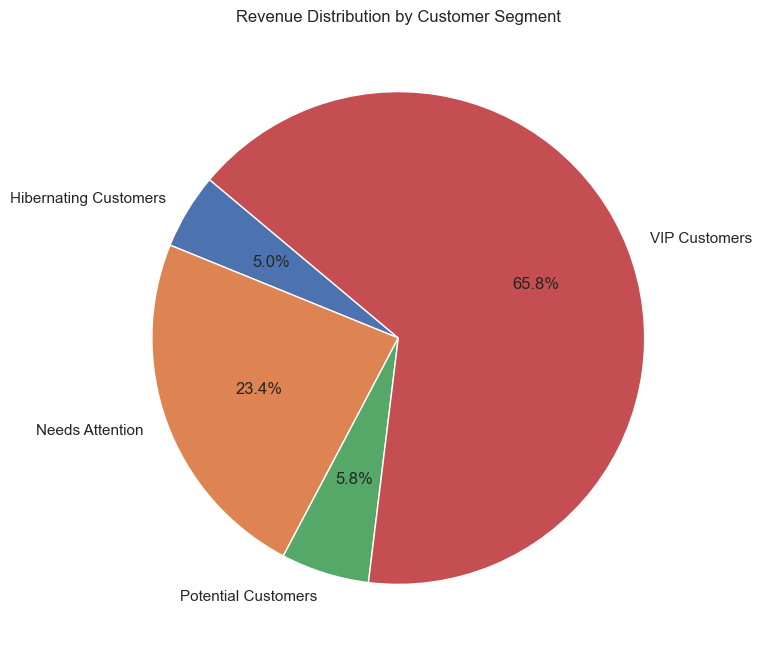

In [57]:
plt.figure(figsize=(8,8))

plt.pie(
    pareto_df['Revenue_Share (%)'],
    labels=pareto_df.index,
    autopct='%1.1f%%',
    startangle=140
)

plt.title('Revenue Distribution by Customer Segment')

plt.show()

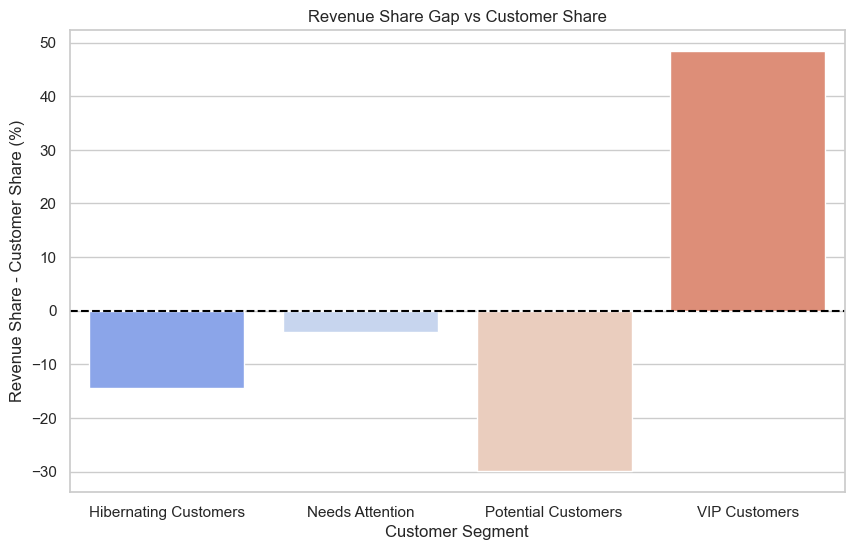

In [61]:
pareto_gap = pareto_df.reset_index()

pareto_gap['Gap'] = (
    pareto_gap['Revenue_Share (%)']
    - pareto_gap['Customer_Share (%)']
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=pareto_gap,
    x='ML_Segment_Name',
    y='Gap',
    hue='ML_Segment_Name',
    palette='coolwarm'
)

plt.axhline(0, color='black', linestyle='--')

plt.title('Revenue Share Gap vs Customer Share')
plt.ylabel('Revenue Share - Customer Share (%)')
plt.xlabel('Customer Segment')

plt.show()

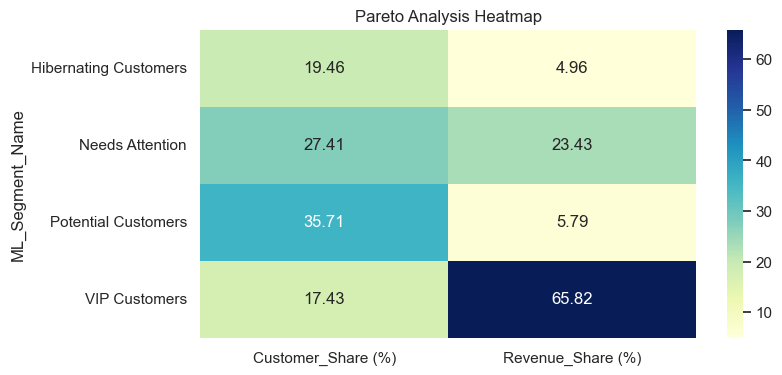

In [59]:
plt.figure(figsize=(8,4))

sns.heatmap(
    pareto_df[['Customer_Share (%)', 'Revenue_Share (%)']],
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Pareto Analysis Heatmap')

plt.show()

Pareto analysis reveals that VIP Customers account for only 17.43% of total customers but contribute 65.82% of total revenue, demonstrating a strong Pareto effect in the business. In contrast, Potential Customers represent the largest customer segment (35.71%) while generating only 5.79% of revenue, indicating significant opportunities for customer conversion and value growth. Meanwhile, Hibernating Customers contribute minimally to revenue despite representing nearly one-fifth of the customer base, suggesting low retention value.

The visualized Pareto analysis demonstrates a strong revenue concentration among VIP Customers, who contribute disproportionately higher revenue relative to their population size. Conversely, Potential Customers account for the largest customer share but generate limited revenue, indicating untapped monetization opportunities. The analysis highlights the importance of retention strategies for high-value customers and conversion strategies for mid-value segments.

The analysis reveals a strong revenue imbalance across customer segments. While VIP Customers form a relatively small portion of the customer base, they generate most of the company’s revenue. Meanwhile, Potential Customers dominate in volume but contribute minimally to revenue, highlighting opportunities for customer value conversion. This suggests that the company should simultaneously protect high-value customers and improve monetization strategies for lower-value segments.